# Predicting Insurance Claim Amounts 

In this kernel, I am going to perform an **Exploratory Data Analysis (EDA)** on the Medical Cost Personal Dataset. I will analyze how different personal and lifestyle factors affect medical insurance charges and build a **Linear Regression** model to predict insurance claim amounts accurately.

### Kernel Outlines:

* **Introduction & Problem Statement**
  Medical insurance costs vary depending on factors such as age, BMI, smoking habits, and number of dependents. The objective of this project is to estimate medical insurance claim charges using machine learning regression techniques.

* **Importing Necessary Packages**
* **Loading the Dataset**
* **Data Cleaning and Preparation**
* **Statistical Summary of the Dataset**
* **Checking Missing Values**
* **Exploratory Data Analysis (EDA)**
* **Data Visualization**
  * Age vs Insurance Charges
  * BMI vs Insurance Charges
  * Smoking Status vs Charges
  * Correlation Heatmap
* **Encoding Categorical Features**
* **Feature Correlation Analysis**
* **Train-Test Split**
* **Feature Scaling (if required)**
* **Training Regression Model**
  * Linear Regression
* **Model Evaluation**
  * Mean Absolute Error (MAE)
  * Root Mean Squared Error (RMSE)
  * R² Score
* **Prediction Visualization**
* **Conclusion & Insights**
### Target
**charges** → Medical insurance claim amount (continuous target variable)
### Skills Demonstrated
* Regression Modeling
* Feature Correlation and Visualization
* Data Preprocessing
* Error Evaluation using MAE and RMSE
* Predictive Analytics using Machine Learning


In [4]:
%pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
print(sys.executable)

c:\Program Files\Python313\python.exe


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

# Read the data and the basic analysis

In [7]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
print("Shape:", df.shape)


Shape: (1338, 7)


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [10]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
#check for duplicates
df.duplicated().sum()


np.int64(1)

In [13]:
df.drop_duplicates(inplace=True)

# statrt EDA

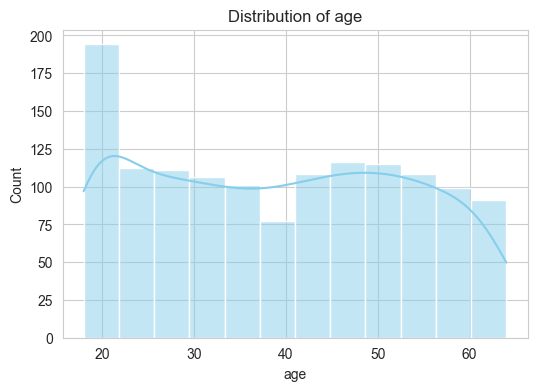

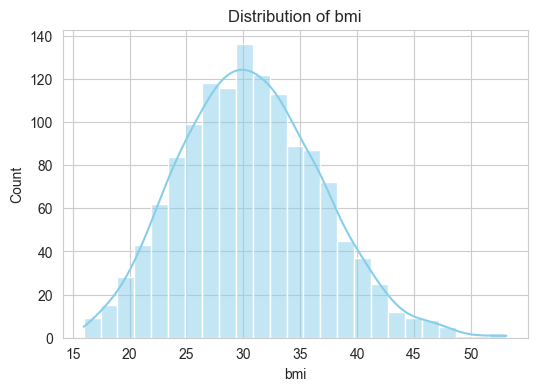

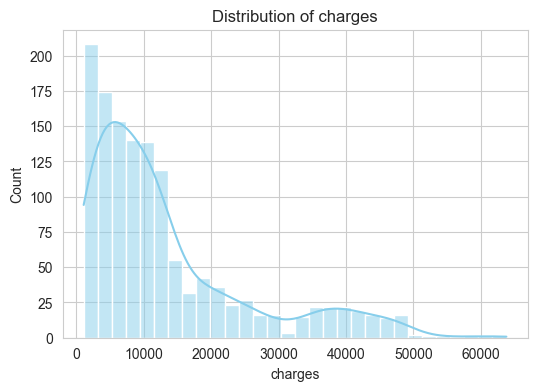

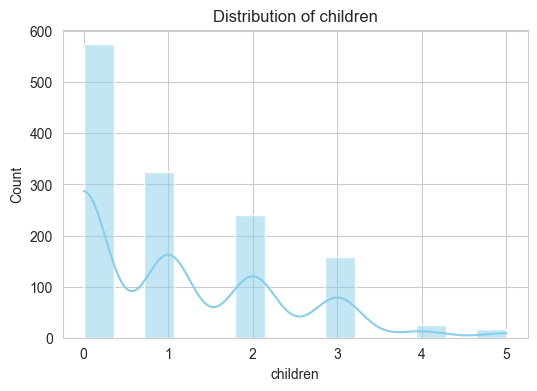

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'bmi', 'charges', 'children']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.show()

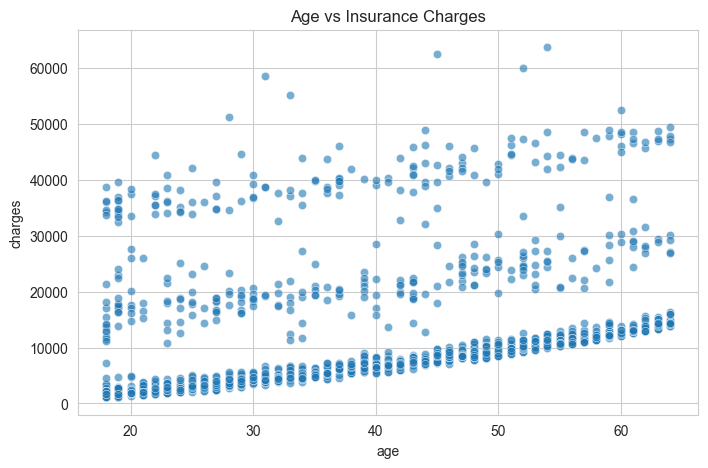

In [50]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df, alpha=0.6)
plt.title("Age vs Insurance Charges")
plt.show()

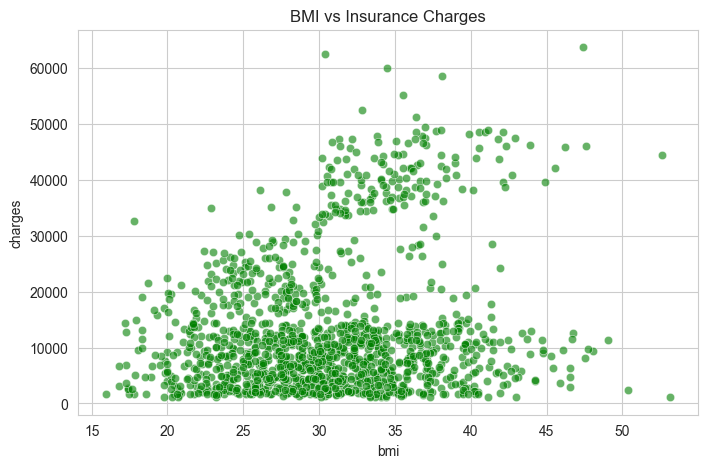

In [51]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', data=df, alpha=0.6, color='green')
plt.title("BMI vs Insurance Charges")
plt.show()

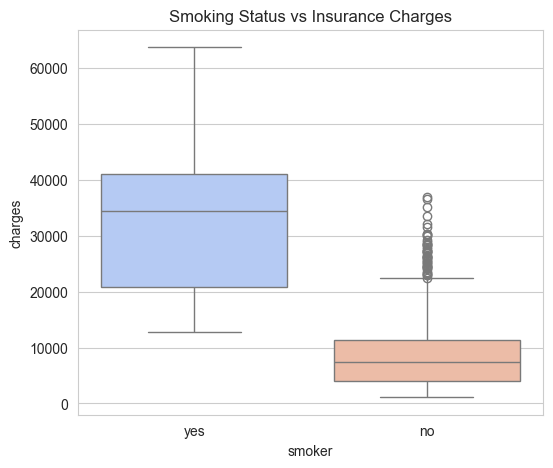

In [52]:
plt.figure(figsize=(6,5))
sns.boxplot(x='smoker', y='charges', data=df, palette="coolwarm")
plt.title("Smoking Status vs Insurance Charges")
plt.show()

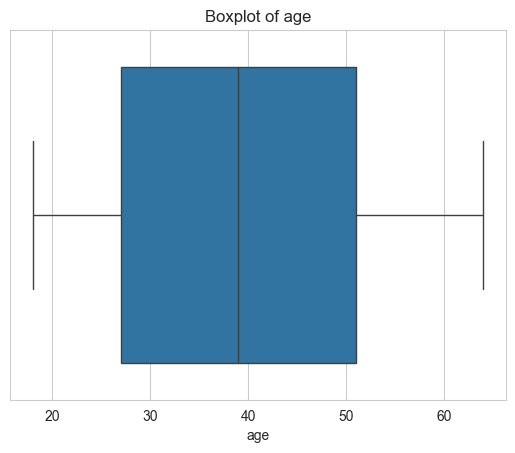

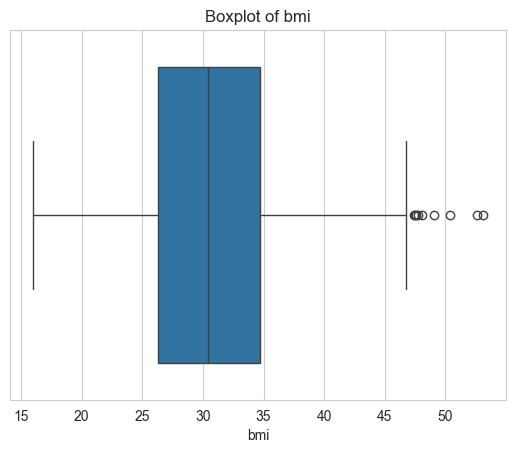

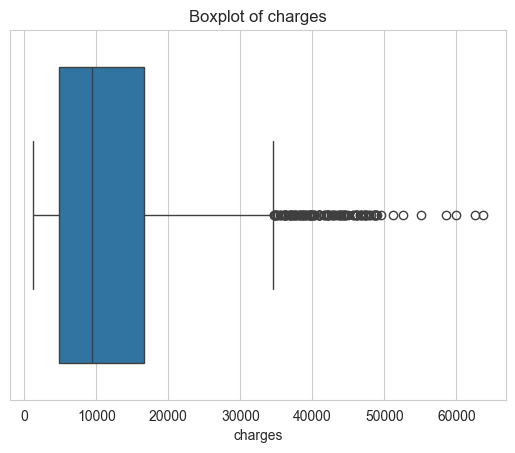

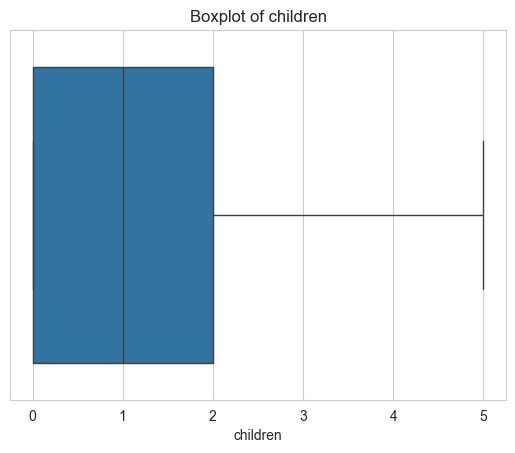

In [53]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

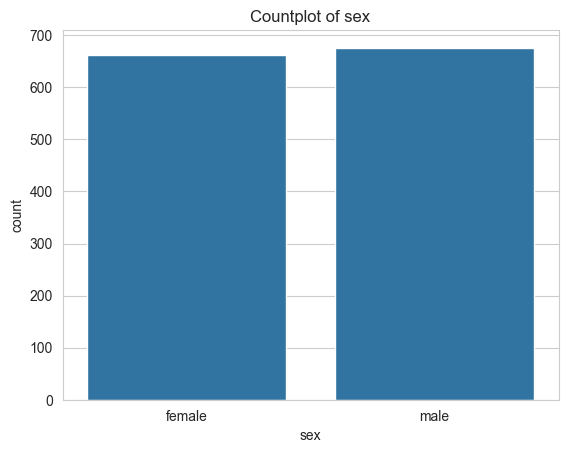

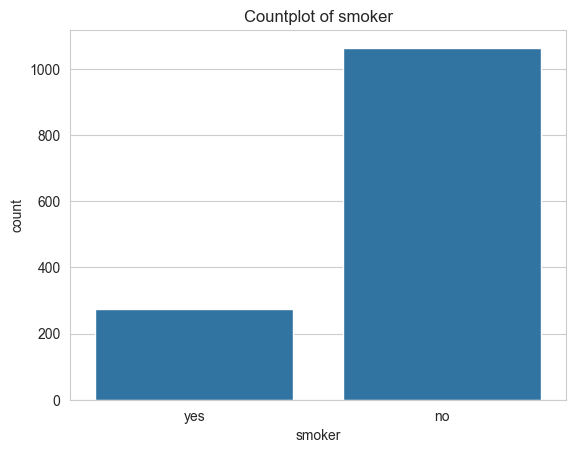

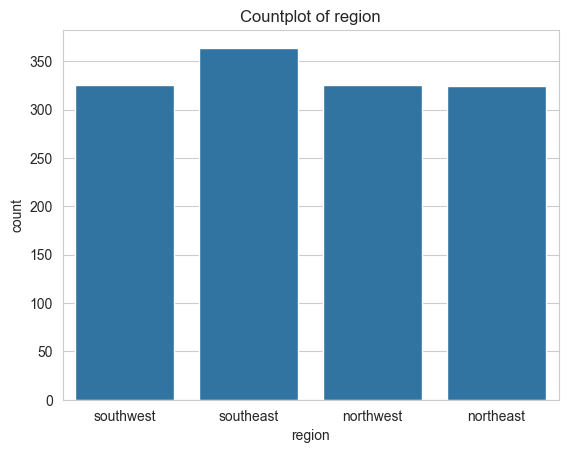

In [54]:
cat_cols = ['sex', 'smoker', 'region']

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.show()

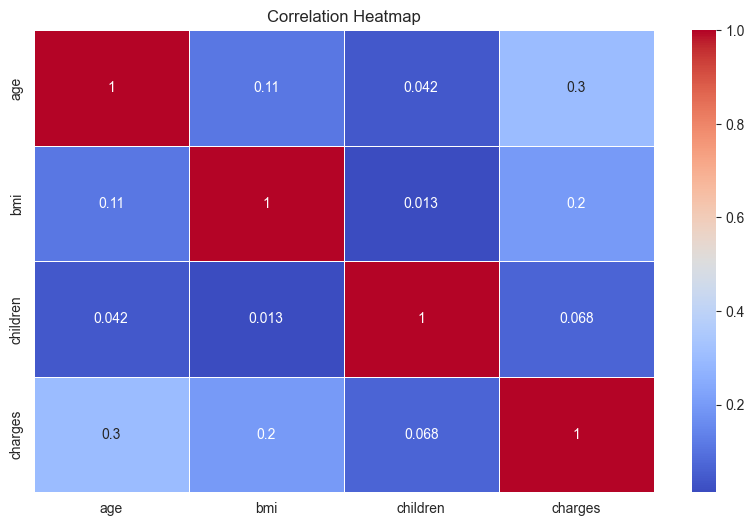

In [55]:
plt.figure(figsize=(10,6))

# only numeric columns
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# Bivariate Analysis

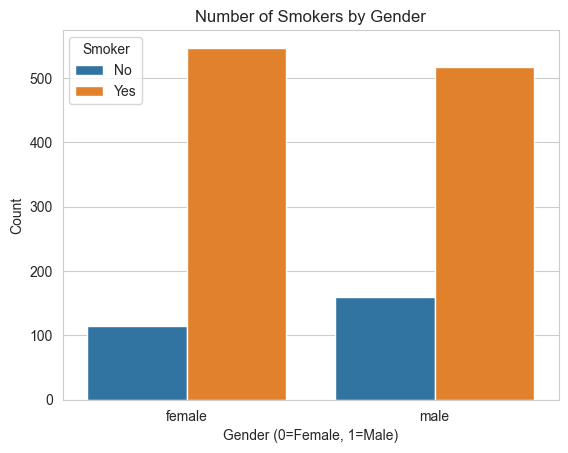

In [60]:

# Count plot for number of smokers by gender
sns.countplot(x='sex', hue='smoker', data=df)
plt.title('Number of Smokers by Gender')
plt.xlabel('Gender (0=Female, 1=Male)')
plt.ylabel('Count')
plt.legend(title='Smoker', labels=['No', 'Yes'])
plt.show()

In [61]:
df.groupby('smoker')['charges'].mean().sort_values(ascending=False)


smoker
yes    32050.231832
no      8434.268298
Name: charges, dtype: float64

In [62]:
df.groupby('sex')['charges'].mean()

sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64

In [63]:
pd.crosstab(df['region'], df['smoker'])

smoker,no,yes
region,,
northeast,257,67
northwest,267,58
southeast,273,91
southwest,267,58


In [64]:
df.groupby('region')['charges'].mean().sort_values(ascending=False)

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

In [65]:
pd.crosstab(df['sex'], df['smoker'])

smoker,no,yes
sex,,
female,547,115
male,517,159


In [66]:
df.groupby('sex')['charges'].sum().sort_values(ascending=False)

sex
male      9.434764e+06
female    8.321061e+06
Name: charges, dtype: float64

In [67]:
pd.crosstab(df['children'], df['smoker'])

smoker,no,yes
children,,
0,459,115
1,263,61
2,185,55
3,118,39
4,22,3
5,17,1


In [68]:
df.groupby(['smoker'])['charges'].mean().sort_values(ascending=False)

smoker
yes    32050.231832
no      8434.268298
Name: charges, dtype: float64

# apply

In [69]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])
df['charges_log']=np.log(df['charges'])
df.head()

,age,sex,bmi,children,smoker,region,charges,charges_log
0,19,0,27.900,0,1,3,16884.92400,9.734176
1,18,1,33.770,1,0,2,1725.55230,7.453302
2,28,1,33.000,3,0,2,4449.46200,8.400538
3,33,1,22.705,0,0,1,21984.47061,9.998092
4,32,1,28.880,0,0,1,3866.85520,8.260197


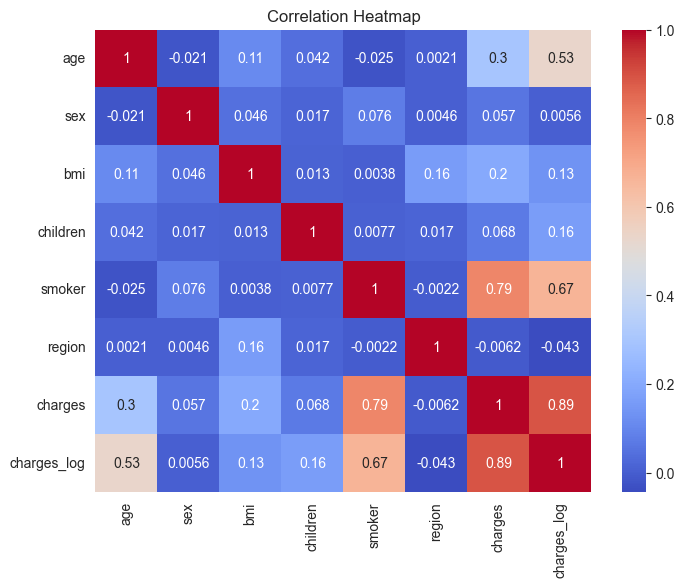

In [70]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

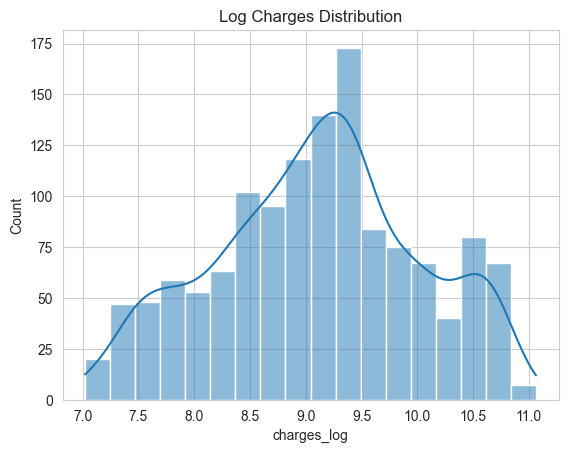

In [71]:
sns.histplot(df['charges_log'], kde=True)
plt.title("Log Charges Distribution")
plt.show()

## Train Test Split

In [72]:
X = df.drop(['charges', 'charges_log'], axis=1)
y = df['charges_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
# normalize the data 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## Training Regression Model

In [74]:
model = LinearRegression()

In [75]:
model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
model.predict(X_test_scaled)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [77]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions (example)
# y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.1775624856272188
Mean Absolute Error: 0.27082052110955845
R^2 Score: 0.8025197916136612


## feature Scaling

In [78]:
X=df.drop(['charges', 'charges_log'], axis=1)
y=df['charges_log']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


In [80]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 0.1775624856272188
R^2 Score: 0.8025197916136612


# FE

In [81]:
df=pd.read_csv("insurance.csv")

In [82]:
newdf=df.copy()
newdf.drop_duplicates(inplace=True)

In [83]:
newdf['bmi_deviation'] = abs(newdf['bmi'] - 22)

newdf['smoker'] = newdf['smoker'].map({'yes':1, 'no':0})

newdf['smoker_intensity'] = newdf['smoker'] * newdf ['age']


newdf['health_index'] = (
    newdf['bmi'] * 0.5 +
    newdf['age'] * 0.3 +
    newdf['smoker'] * 30
)


newdf['high_risk'] = (
    (newdf['smoker'] == 1) &
    (newdf['bmi'] > 30) &
    (newdf['age'] > 50)
).astype(int)


newdf['age_bmi_smoker'] = newdf['age'] * newdf['bmi'] * newdf['smoker']
newdf.head()

,age,sex,bmi,children,smoker,region,charges,bmi_deviation,smoker_intensity,health_index,high_risk,age_bmi_smoker
0,19,female,27.900,0,1,southwest,16884.92400,5.900,19,49.6500,0,530.1
1,18,male,33.770,1,0,southeast,1725.55230,11.770,0,22.2850,0,0.0
2,28,male,33.000,3,0,southeast,4449.46200,11.000,0,24.9000,0,0.0
3,33,male,22.705,0,0,northwest,21984.47061,0.705,0,21.2525,0,0.0
4,32,male,28.880,0,0,northwest,3866.85520,6.880,0,24.0400,0,0.0


In [84]:
newdf['charges']=np.log(newdf['charges'])

In [85]:
newdf['sex']=newdf['sex'].map({'male':1, 'female':0})
newdf['region']=newdf['region'].map({'southeast':0, 'southwest':1, 'northeast':2, 'northwest':3})


In [86]:
# the colloraiton between the new features and the target variable
correlation = newdf.corr(numeric_only=True)['charges'].sort_values(ascending=False)
print(correlation)

charges             1.000000
health_index        0.809735
smoker              0.665718
age_bmi_smoker      0.655717
smoker_intensity    0.643718
age                 0.526927
high_risk           0.309624
children            0.160336
bmi                 0.132822
bmi_deviation       0.122175
sex                 0.007009
region             -0.001518
Name: charges, dtype: float64


In [87]:
X=newdf.drop(['charges',], axis=1)
y=newdf['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")


Mean Squared Error: 0.12859272441877742
R^2 Score: 0.861457134924426


In [88]:
import joblib

joblib.dump(model, "model.pkl")

joblib.dump(X.columns, "features.pkl")

['features.pkl']